# Comparing Marani-Inspired and Bernstein: Sensitivity to 1901-Present

- **Summary**: This document compares the our modified method from [Marani et al. (2021)](https://doi.org/10.1073/pnas.2105482118) and the method from [Bernstein et al. (2022)](https://doi.org/10.1126/sciadv.abl4183) using Marani's data. We test the effect of using data from 1901-present (instead of 1600-present) on our modified Marani method.

- **Data Required:** `epidemics_marani_240816.xlsx`

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Sep 3, 2024

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.integrate import quad
from scipy.stats import genpareto
from scipy.optimize import minimize

## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## 0. Prepare respiratory viral epidemic data

In [2]:
## Read epidemic data from Marani et al. 
df = pd.read_excel("data/epidemics_marani_240816.xlsx")
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)

## Subset to respiratory viral epidemics
df_resp_viral = df[df['disease'].isin(['influenza', 'covid-19', 'mers', 'sars'])
                  ].reset_index(drop=True)


In [3]:
## Display all respiratory viral epidemics between 1500-present
# df_resp_viral

## 1. Set up exceedance probabilities from Madhav

In [4]:
## Create Madhav exceedance
severity = [0.001, 0.002, 7.2, 28, 45, 86, 150, 200, 220, 250, 280]
exceedance = [0.2, 0.1, 0.05, 0.02857, 0.02, 0.01, 0.005, 0.003, 0.002, 0.0015, 0.001]

df_madhav = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Save to exceedance results folder
# df_madhav.to_excel("exceedance_results/madhav_original.xlsx", index=False)


## 2. Calibrate our Marani-inspired method with 1901-present data

In [5]:
## Subset epidemics to those with observable severities
df_resp_viral_known = df_resp_viral[df_resp_viral['death_thousand'] > 0
                                   ].reset_index(drop=True)

## Subset epidemics to those in the last century
df_resp_viral_known = df_resp_viral_known[
                        df_resp_viral_known['year_start'] > 1900
                                        ].reset_index(drop=True)


In [6]:
## Subset epidemic data to 1600-present
df_marani_inspired = df_resp_viral[(df_resp_viral["year_start"] > 1900)].reset_index(drop=True)

## Set severity threshold to 0.01 SMU
thresh = 0.01

## Subset to threshold-exceeding respiratory viral epidemics
df_marani_inspired_exceed = df_marani_inspired[df_marani_inspired['severity_smu'] >= thresh].reset_index(drop=True)


In [7]:
## Display Marani-inspired data for GPD
df_marani_inspired_exceed

,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,pandemic spanish flu,1918,1920,3,32000.0,1873300.0,17.082154,170.821545,influenza,viral,droplet,1,0,1,1
1,pandemic of asian flu,1957,1958,2,2000.0,2873306.0,0.696062,6.960623,influenza,viral,droplet,1,0,1,1
2,hong kong flu,1968,1969,2,1000.0,3551599.0,0.281563,2.815633,influenza,viral,droplet,1,0,1,1
3,swine flu,2009,2009,1,284.5,6872767.0,0.041395,0.413953,influenza,viral,droplet,1,0,1,1
4,global covid-19,2019,2024,6,7100.0,7740000.0,0.917313,9.173127,covid-19,viral,airborne/droplet,1,0,1,1


In [8]:
## Fit generalized Pareto distribution on extreme epidemics
params_marani_inspired = genpareto.fit(df_marani_inspired_exceed['severity_smu'], floc=thresh)

## Print results
print(params_marani_inspired)

(1.3911490201494356, 0.01, 4.919578645628762)


In [9]:
## Find arrival rate of threshold-exceeding epidemics during 2000 to 2019
arrival_severe_marani_inspired = df_marani_inspired_exceed[(df_marani_inspired_exceed['year_start'] >= 2000) & 
                                                           (df_marani_inspired_exceed['year_start'] <= 2019)
                                                          ].shape[0] / 20

## Print arrival rate of threshold-exceeding events
print(f'Extreme epidemic arrival rate: {round(arrival_severe_marani_inspired, 3)}/year')


Extreme epidemic arrival rate: 0.1/year


In [10]:
## Calculate exceedance probabilities
exceedance = arrival_severe_marani_inspired * (1 - genpareto.cdf(severity, 
                                                                 *params_marani_inspired))

df_marani_inspired_1901 = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Sort and reset index (optional)
df_marani_inspired_1901 = df_marani_inspired_1901.sort_values(by='severity', ascending=True)
df_marani_inspired_1901 = df_marani_inspired_1901.reset_index(drop=True)

In [11]:
## Display exceedance results
df_marani_inspired_1901

## Save to exceedance results folder
df_marani_inspired_1901.to_excel("exceedance_results/marani_inspired_1901.xlsx", index=False)

,severity,exceedance
0,0.001,0.100000
1,0.002,0.100000
2,7.200,0.045040
3,28.000,0.020750
4,45.000,0.015219
5,86.000,0.009799
6,150.000,0.006650
7,200.000,0.005430
8,220.000,0.005076
9,250.000,0.004637


## 3. Calculate empirical exceedance probabilities from 1901-present

In [12]:
df_resp_viral_known

,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,pandemic spanish flu,1918,1920,3,32000.000,1.873300e+06,17.082154,170.821545,influenza,viral,droplet,1,0,1,1
1,"salomon islands, ontong java",1926,1926,1,0.033,2.020467e+06,0.000016,0.000163,influenza,viral,droplet,1,0,1,0
2,pandemic of asian flu,1957,1958,2,2000.000,2.873306e+06,0.696062,6.960623,influenza,viral,droplet,1,0,1,1
3,hong kong flu,1968,1969,2,1000.000,3.551599e+06,0.281563,2.815633,influenza,viral,droplet,1,0,1,1
4,papua new guinea,1969,1970,2,3.000,3.625681e+06,0.000827,0.008274,influenza,viral,droplet,1,0,1,0
5,global sars,2003,2003,1,0.744,6.381185e+06,0.000117,0.001166,sars,viral,droplet,1,0,1,1
6,swine flu,2009,2009,1,284.500,6.872767e+06,0.041395,0.413953,influenza,viral,droplet,1,0,1,1
7,global mers,2012,2017,6,0.659,7.125828e+06,0.000092,0.000925,mers,viral,droplet,1,0,1,1
8,indian swine flu outbreak,2015,2015,1,2.000,7.379797e+06,0.000271,0.002710,influenza,viral,droplet,1,0,1,0
9,global covid-19,2019,2024,6,7100.000,7.740000e+06,0.917313,9.173127,covid-19,viral,airborne/droplet,1,0,1,1


In [13]:
## Set arrival rate epidemics with known severities conditional upon first arrival
arrival_known = (df_resp_viral_known.shape[0] - 1) / (2019 - 1918)

## Create a ranked df by historical severities 
df_resp_viral_ranked = df_resp_viral_known.sort_values(by='severity_smu', 
                                                       ascending=False).reset_index(drop=True)

## Calculate exceedance conditional on known-severity arrival
df_resp_viral_ranked['exceed_upon_arrival'] = (df_resp_viral_ranked.index + 1) / (df_resp_viral_ranked.shape[0] + 1)

## Create empirical exceedance probabilities
df_resp_viral_ranked['exceedance'] = arrival_known * df_resp_viral_ranked['exceed_upon_arrival']

In [14]:
## Create df for empirical exceedance
df_empirical_1901 = pd.DataFrame({
    'severity': df_resp_viral_ranked['severity_smu'],
    'exceedance': df_resp_viral_ranked['exceedance'],
    'year_start': df_resp_viral_ranked['year_start'],
    'disease': df_resp_viral_ranked['disease']
})

## Display
df_empirical_1901

## Save to exceedance results folder
df_empirical_1901.to_excel("exceedance_results/empirical_1901.xlsx", index=False)


,severity,exceedance,year_start,disease
0,170.821545,0.008101,1918,influenza
1,9.173127,0.016202,2019,covid-19
2,6.960623,0.024302,1957,influenza
3,2.815633,0.032403,1968,influenza
4,0.413953,0.040504,2009,influenza
5,0.008274,0.048605,1969,influenza
6,0.002710,0.056706,2015,influenza
7,0.001166,0.064806,2003,sars
8,0.000925,0.072907,2012,mers
9,0.000163,0.081008,1926,influenza


## 4. Visualize models on 1901-present data and empirical exceedance

In [15]:
## Read exceedance results from benchmark models
df_marani_inspired = pd.read_excel("exceedance_results/marani_inspired.xlsx")
df_bernstein = pd.read_excel("exceedance_results/bernstein_original.xlsx")


<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Epidemic Severity (SMU, or deaths per 10,000 people)')

Text(0, 0.5, 'Annual Exceedance Probability')

Text(0.5, 1.0, 'Exceedance Probability of Respiratory Viral Epidemics')

(0.0001, 1.0)

(0.01, 1000.0)

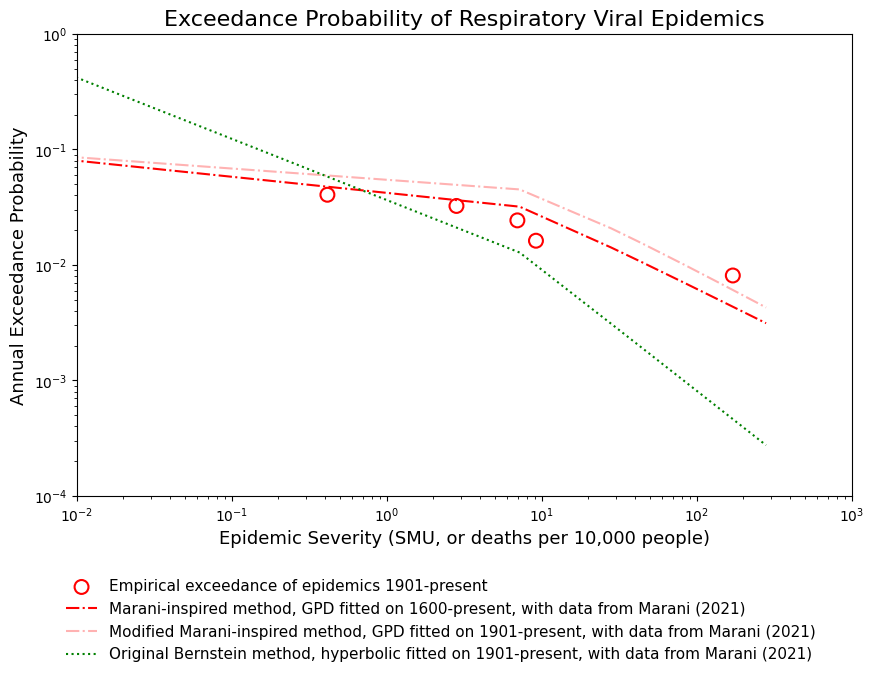

In [16]:
## Plot comparison across Madhav, Marani, and Bernstein-Fan 
plt.figure(figsize=(10, 6))


## Plot empirical exceedances of epidemics from 1901-present
plt.scatter(df_empirical_1901['severity'], df_empirical_1901['exceedance'], 
            edgecolor='red', facecolor='none', s=100, linewidth=1.5,
            label='Empirical exceedance of epidemics 1901-present')


## Plot for Marani-inspired
plt.plot(df_marani_inspired['severity'], df_marani_inspired['exceedance'], 
         color='red', linestyle='-.', alpha=1,
         label='Marani-inspired method, GPD fitted on 1600-present, with data from Marani (2021)')


## Plot for Marani-inspired fitted on 1901-present data
plt.plot(df_marani_inspired_1901['severity'], df_marani_inspired_1901['exceedance'], 
         color='red', linestyle='-.', alpha=0.3,
         label='Modified Marani-inspired method, GPD fitted on 1901-present, with data from Marani (2021)')


## Plot for Bernstein original
plt.plot(df_bernstein['severity'], df_bernstein['exceedance'], 
         color='green', linestyle=':', alpha=1,
         label='Original Bernstein method, hyperbolic fitted on 1901-present, with data from Marani (2021)')

# ## Plot for Madhav
# plt.plot(df_madhav['severity'], df_madhav['exceedance'], 
#          color='purple', linestyle='-', label='Original simulated results from Madhav')

## Add labels and title
plt.xlabel('Epidemic Severity (SMU, or deaths per 10,000 people)', fontsize=13)
plt.ylabel('Annual Exceedance Probability', fontsize=13)
plt.title('Exceedance Probability of Respiratory Viral Epidemics', fontsize=16)

## Set y-axis scale and limits
plt.yscale('log')
plt.ylim(1e-4, 1e0)

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-2, 1e3)
# plt.xlim(0, 300)

## Adding legend below the plot in 1 column without frame
plt.legend(loc='upper center', bbox_to_anchor=(0.47, -0.15), 
           ncol=1, frameon=False, fontsize=11)

## Save graph as jpg file at 400 dpi
plt.savefig('graphs/06b_sensitivity_data_1901.jpg', dpi=400, bbox_inches = 'tight')

## Display
plt.show()


<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Epidemic Severity (SMU, or deaths per 10,000 people)')

Text(0, 0.5, 'Annual Exceedance Probability')

Text(0.5, 1.0, 'Exceedance Probability of Respiratory Viral Epidemics')

(0.0001, 1.0)

(0.01, 1000.0)

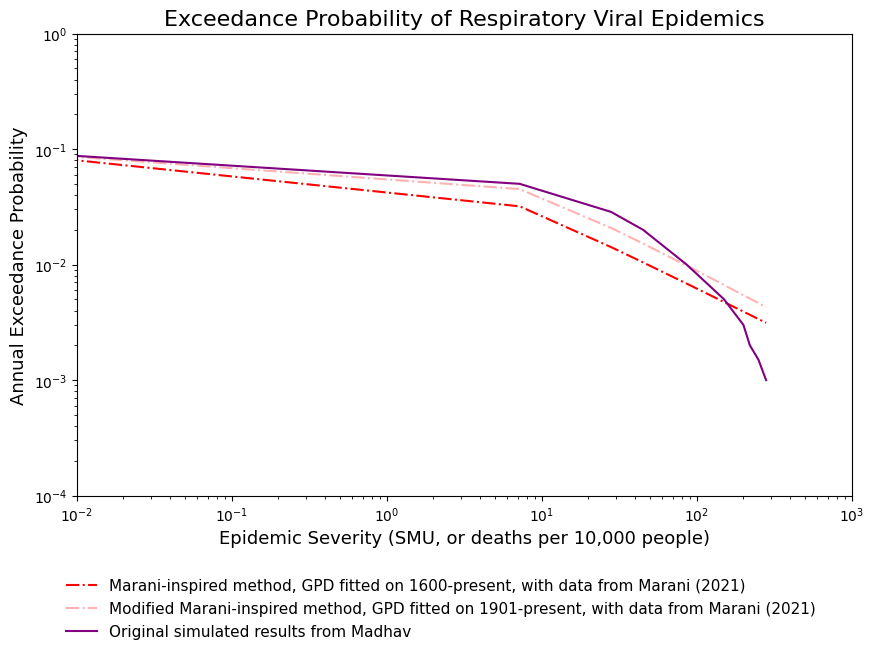

In [19]:
## Plot comparison across Madhav, Marani, and Bernstein-Fan 
plt.figure(figsize=(10, 6))


# ## Plot empirical exceedances of epidemics from 1901-present
# plt.scatter(df_empirical_1901['severity'], df_empirical_1901['exceedance'], 
#             edgecolor='red', facecolor='none', s=100, linewidth=1.5,
#             label='Empirical exceedance of epidemics 1901-present')


## Plot for Marani-inspired
plt.plot(df_marani_inspired['severity'], df_marani_inspired['exceedance'], 
         color='red', linestyle='-.', alpha=1,
         label='Marani-inspired method, GPD fitted on 1600-present, with data from Marani (2021)')


## Plot for Marani-inspired fitted on 1901-present data
plt.plot(df_marani_inspired_1901['severity'], df_marani_inspired_1901['exceedance'], 
         color='red', linestyle='-.', alpha=0.3,
         label='Modified Marani-inspired method, GPD fitted on 1901-present, with data from Marani (2021)')


# ## Plot for Bernstein original
# plt.plot(df_bernstein['severity'], df_bernstein['exceedance'], 
#          color='green', linestyle=':', alpha=1,
#          label='Original Bernstein method, hyperbolic fitted on 1901-present, with data from Marani (2021)')

## Plot for Madhav
plt.plot(df_madhav['severity'], df_madhav['exceedance'], 
         color='purple', linestyle='-', label='Original simulated results from Madhav')

## Add labels and title
plt.xlabel('Epidemic Severity (SMU, or deaths per 10,000 people)', fontsize=13)
plt.ylabel('Annual Exceedance Probability', fontsize=13)
plt.title('Exceedance Probability of Respiratory Viral Epidemics', fontsize=16)

## Set y-axis scale and limits
plt.yscale('log')
plt.ylim(1e-4, 1e0)

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-2, 1e3)
# plt.xlim(0, 300)

## Adding legend below the plot in 1 column without frame
plt.legend(loc='upper center', bbox_to_anchor=(0.47, -0.15), 
           ncol=1, frameon=False, fontsize=11)

## Save graph as jpg file at 400 dpi
# plt.savefig('graphs/06b_sensitivity_data_1901_madhav_comp.jpg', dpi=400, bbox_inches = 'tight')

## Display
plt.show()

